In [124]:
import rasterio
from dist_s1.dist_plot import get_dist_s1_mpl_cmap
import matplotlib.pyplot as plt
import numpy as np
from dem_stitcher.rio_window import read_raster_from_window
from dist_s1_enumerator.mgrs_burst_data import get_mgrs_table
import pandas as pd
from pathlib import Path
from tile_mate import get_raster_from_tiles
from dem_stitcher.rio_tools import reproject_arr_to_match_profile

In [161]:
MGRS_TILE_ID = '50NPL' #'19LCF' #'50NPL' # '20LMM' '20MMA'


In [162]:
val_dist_dir = Path('../Zg_validation_variation/val_products_transformer_optimized-max10_processed_2026-02-05/')
other_dist_dir = Path('../Zg_validation_variation/informal_val_sites_transformer_optimized-max10_processed_2026-02-05/')
ts_dir = (list(val_dist_dir.glob(f'*_{MGRS_TILE_ID}/')) + list(other_dist_dir.glob(f'*_{MGRS_TILE_ID}/')))[0]
ts_dir

PosixPath('../Zg_validation_variation/val_products_transformer_optimized-max10_processed_2026-02-05/treelosswet__50NPL')

In [163]:
status_files = sorted(list(ts_dir.rglob('OPERA*_GEN-DIST-STATUS.tif')))
status_files[:3]

[PosixPath('../Zg_validation_variation/val_products_transformer_optimized-max10_processed_2026-02-05/treelosswet__50NPL/OPERA_L3_DIST-ALERT-S1_T50NPL_20240105T215803Z_20260205T195711Z_S1A_30_v0.1/OPERA_L3_DIST-ALERT-S1_T50NPL_20240105T215803Z_20260205T195711Z_S1A_30_v0.1_GEN-DIST-STATUS.tif'),
 PosixPath('../Zg_validation_variation/val_products_transformer_optimized-max10_processed_2026-02-05/treelosswet__50NPL/OPERA_L3_DIST-ALERT-S1_T50NPL_20240112T214955Z_20260205T195137Z_S1A_30_v0.1/OPERA_L3_DIST-ALERT-S1_T50NPL_20240112T214955Z_20260205T195137Z_S1A_30_v0.1_GEN-DIST-STATUS.tif'),
 PosixPath('../Zg_validation_variation/val_products_transformer_optimized-max10_processed_2026-02-05/treelosswet__50NPL/OPERA_L3_DIST-ALERT-S1_T50NPL_20240117T215802Z_20260205T191908Z_S1A_30_v0.1/OPERA_L3_DIST-ALERT-S1_T50NPL_20240117T215802Z_20260205T191908Z_S1A_30_v0.1_GEN-DIST-STATUS.tif')]

In [164]:
def get_acq_time(path):
    opera_id = path.stem
    tokens = opera_id.split('_')
    acq_time = pd.to_datetime(tokens[4])
    return acq_time

ts_start = get_acq_time(status_files[0])
ts_end = get_acq_time(status_files[-1])
ts_start, ts_end


(Timestamp('2024-01-05 21:58:03+0000', tz='UTC'),
 Timestamp('2024-12-30 21:57:58+0000', tz='UTC'))

In [165]:
COMP_DIR = Path(f'comparison_dir / {MGRS_TILE_ID}')
COMP_DIR.mkdir(exist_ok=True, parents=True)

In [166]:
RADD_PATH = list(Path('.').glob(f'radd_data/RADD*{MGRS_TILE_ID}*.tif'))[0]
RADD_PATH

PosixPath('radd_data/RADD_FullStack_2026-03-22_50NPL.tif')

In [167]:
AUX_DATA = Path('aux_data')
AUX_DATA.mkdir(exist_ok=True)

In [168]:
df_mgrs = get_mgrs_table()
df_mgrs_tile = df_mgrs[df_mgrs['mgrs_tile_id'] == MGRS_TILE_ID]
mgrs_bounds = df_mgrs_tile.total_bounds.tolist()
mgrs_bounds 

[117.901317933201, 4.43248342704375, 118.893506054657, 5.4275513419105]

In [169]:
# LANDCOVER_PATH = AUX_DATA / f'{MGRS_TILE_ID}_landcover_umd_lc.tif'
# if not LANDCOVER_PATH.exists():
#     X_glad, p_glad = get_raster_from_tiles(mgrs_bounds, 'glad_landcover', year=2020)
#     with rasterio.open(LANDCOVER_PATH, 'w', **p_glad) as dst:
#         dst.write(X_glad)
# else:
#     with rasterio.open(LANDCOVER_PATH) as src:
#         p_glad = src.profile
#         X_glad = src.read()

In [170]:
# HANSEN_LOSS_YEAR = AUX_DATA / f'{MGRS_TILE_ID}_hansen_lossyear.tif'
# if not HANSEN_LOSS_YEAR.exists():
#     X_ly, p_ly = get_raster_from_tiles(mgrs_bounds, 'hansen_lossyear')
#     with rasterio.open(HANSEN_LOSS_YEAR, 'w', **p_ly) as dst:
#         dst.write(X_ly)
# else:
#     with rasterio.open(HANSEN_LOSS_YEAR) as src:
#         p_ly = src.profile
#         X_ly = src.read()

In [171]:
with rasterio.open(RADD_PATH) as src:
    X_fb = src.read(3)
    p_fb = src.profile

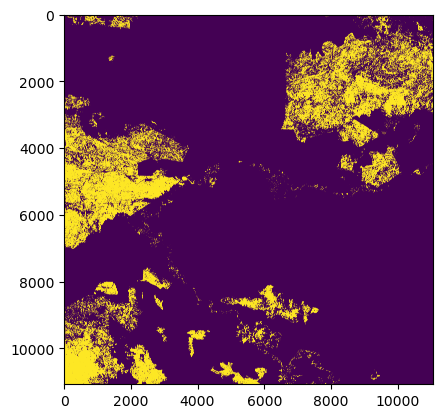

In [172]:
X_fb_mask =(X_fb == 1)
plt.imshow(X_fb_mask)

In [173]:
# LANDCOVER_PATH = Path(f'{MGRS_TILE_ID}_landcover_esa_2021.tif')
# if not LANDCOVER_PATH.exists():
#     X_esa, p_esa = get_raster_from_tiles(mgrs_bounds, 'esa_world_cover_2021')
#     with rasterio.open(LANDCOVER_PATH, 'w', **p_esa) as dst:
#         dst.write(X_esa)
# else:
#     with rasterio.open(LANDCOVER_PATH) as src:
#         p_esa = src.profile
#         X_esa = src.read(1)

In [174]:
# ly_mask_r, _ = reproject_arr_to_match_profile(fb_mask, p_fb, p_glad,  resampling='nearest')
# ly_mask_r = ly_mask_r[0, ...].astype(bool)
# X_glad_mask = ~(np.isin(X_glad[0, ...],  terra_firma_tree_cover))
# X_mask = (X_glad_mask | ly_mask_r).astype(np.uint8)
# plt.imshow(X_mask)

In [175]:
MASK_PATH = AUX_DATA / f'mask_{MGRS_TILE_ID}_forest_baseline.tif'

In [176]:
p_fb.update(count=1, dtype=np.uint8)
with rasterio.open(MASK_PATH, 'w', **p_fb) as dst:
    dst.write(X_fb_mask, 1)


In [177]:
X_radd, p_radd = read_raster_from_window(RADD_PATH, mgrs_bounds)

In [178]:
radd_alert = X_radd[0, ...]
radd_date = X_radd[1, ...]

In [179]:
alert_f = np.zeros(radd_alert.shape, dtype=np.uint8)
alert_f[radd_alert == 3] = 6
alert_f[np.isin(radd_alert, [1, 2])] = 3

dist_cmap, dist_norm = get_dist_s1_mpl_cmap()


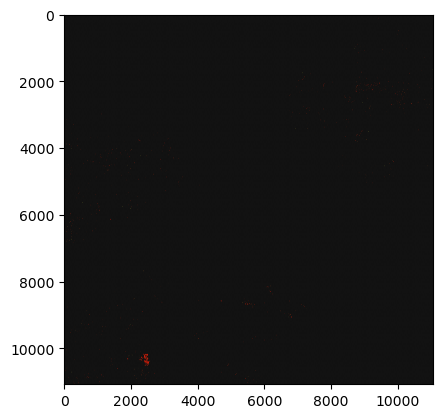

In [180]:
plt.imshow(alert_f, norm=dist_norm, cmap=dist_cmap)


In [181]:
radd_date_year = radd_date // 1000
radd_day_of_year = radd_date % 1000

In [182]:
np.max(radd_date_year)

np.int16(26)

In [183]:
ts_start.year

2024

In [184]:
assert (ts_start.year == ts_end.year)
radd_year_filter = (radd_date_year == int(str(ts_start.year)[-2:]))

In [185]:
day_start = (ts_start - pd.Timestamp(f'{ts_start.year}-01-01', tz='UTC')).days
day_end = (ts_end - pd.Timestamp(f'{ts_start.year}-01-01', tz='UTC')).days
day_start, day_end

(4, 364)

In [186]:
radd_filter = (radd_day_of_year >= day_start) & (radd_day_of_year <= day_end) #& radd_year_filter

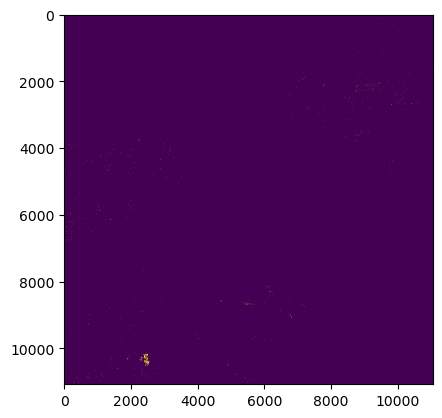

In [187]:
plt.imshow(radd_filter)

In [188]:
radd_alerts_2024 = np.zeros(radd_alert.shape, dtype=np.uint8)
radd_alerts_2024[(radd_date_year==24)] = 6

# All confirmed

In [189]:
def open_one_arr(path):
    with rasterio.open(path) as src:
        return src.read(1)

status_arrs = list(map(open_one_arr, status_files))
status_arrs_stacked = np.stack(status_arrs, axis=0)

with rasterio.open(status_files[0]) as src:
    p_dist = src.profile
    cmap_dist = src.colormap(1)


In [190]:
confirmed_low_mask = (status_arrs_stacked == 3).any(axis=0)
confirmed_high_mask = (status_arrs_stacked == 6).any(axis=0)

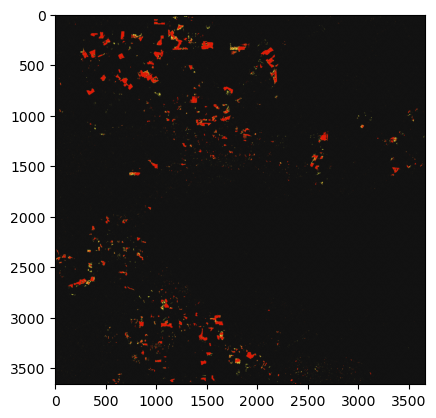

In [191]:
status_agg = np.zeros(status_arrs_stacked.shape[1:], dtype=np.uint8)
status_agg[confirmed_low_mask] = 3
status_agg[confirmed_high_mask] = 6
plt.imshow(status_agg, cmap=dist_cmap, norm=dist_norm)


In [192]:
X_mask_dist_s1, _ = reproject_arr_to_match_profile(X_fb_mask.astype(np.uint8), p_fb, p_dist, resampling='nearest')
X_mask_dist_s1 = X_mask_dist_s1[0, ...].astype(bool)

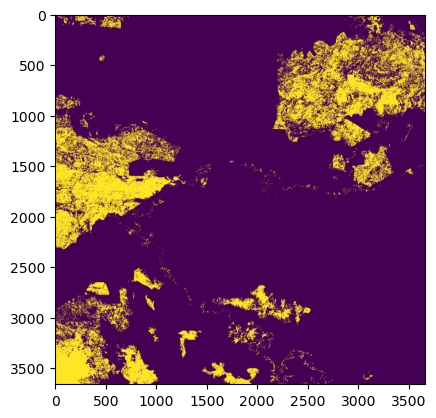

In [193]:
plt.imshow(X_mask_dist_s1)

In [194]:
with rasterio.open(COMP_DIR / f'{MGRS_TILE_ID}_status_agg_all.tif', 'w', **p_dist) as dst:
    dst.write(status_agg, 1)
    dst.write_colormap(1, cmap_dist)

status_agg_masked = status_agg.copy()

status_agg_masked[~X_mask_dist_s1] = 0
with rasterio.open(COMP_DIR / f'{MGRS_TILE_ID}_status_agg_masked.tif', 'w', **p_dist) as dst:
    dst.write(status_agg_masked, 1)
    dst.write_colormap(1, cmap_dist)

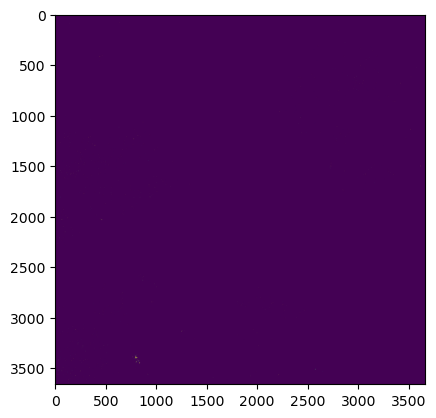

In [195]:
plt.imshow(status_agg_masked)

In [196]:
p_2024 = p_radd.copy()
p_2024['count'] = 1
p_2024['dtype'] = 'uint8'
with rasterio.open(COMP_DIR / f'radd_{ts_end.year}_alerts.tif', 'w', **p_2024) as ds:
    ds.write(radd_alerts_2024, 1)
    ds.write_colormap(1, cmap_dist)